Berdasarkan hasil pengecekan, tidak ditemukan data duplikat pada dataset akhir.

#### Outlier Detection and Handling

Pada tahap ini dilakukan pengecekan outlier pada kolom numerik, yaitu Quantity, Price Per Unit, dan Total Spent. 
Metode yang digunakan adalah Interquartile Range (IQR), yaitu metode yang mendeteksi outlier berdasarkan batas bawah dan batas atas dari distribusi data.

Rumus yang digunakan:

- Q1 = kuartil pertama
- Q3 = kuartil ketiga
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR

Data yang berada di bawah lower bound atau di atas upper bound akan dianggap sebagai outlier.

In [32]:
# Mengecek outlier menggunakan metode IQR
numerical_columns = ['Quantity', 'Price Per Unit', 'Total Spent']

for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"{col}")
    print("Jumlah outlier:", len(outliers))
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("-" * 30)

Quantity
Jumlah outlier: 0
Lower Bound: -1.0
Upper Bound: 7.0
------------------------------
Price Per Unit
Jumlah outlier: 0
Lower Bound: -1.0
Upper Bound: 7.0
------------------------------
Total Spent
Jumlah outlier: 259
Lower Bound: -8.0
Upper Bound: 24.0
------------------------------


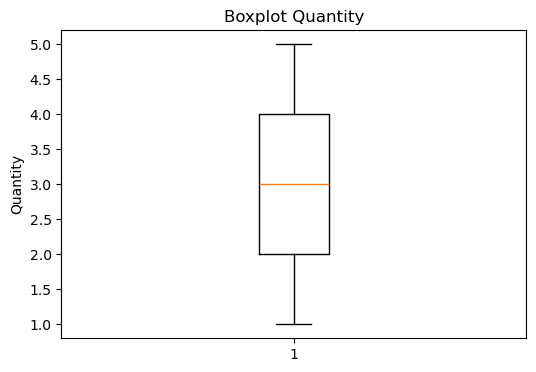

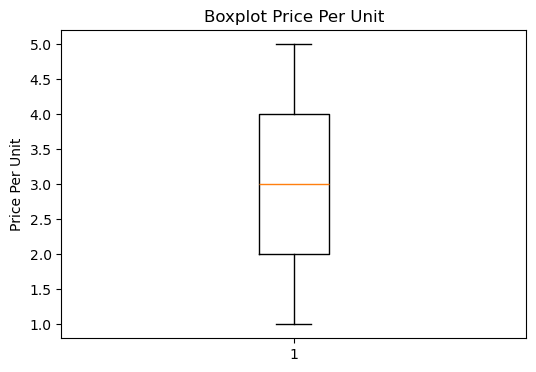

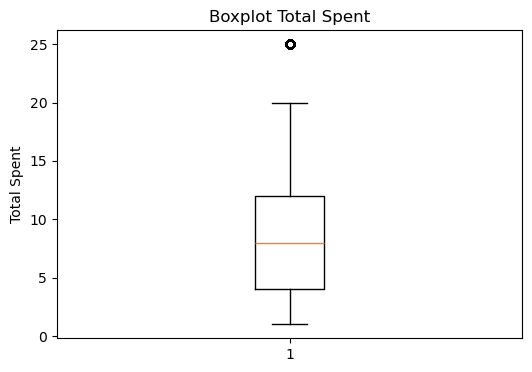

In [33]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot {col}')
    plt.ylabel(col)
    plt.show()

In [34]:
df_capped = df.copy()

for col in numerical_columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)

Berdasarkan hasil pengecekan menggunakan metode IQR, outlier hanya ditemukan pada kolom Total Spent sebanyak 259 data. Sementara itu, kolom Quantity dan Price Per Unit tidak memiliki outlier.

Outlier pada Total Spent tidak langsung dihapus karena masih memungkinkan terjadi dalam transaksi, misalnya ketika pelanggan membeli item dengan Quantity tinggi dan Price Per Unit tinggi. Oleh karena itu, penanganan dilakukan menggunakan capping pada dataframe salinan agar data utama tetap aman.